# Lecture 3: Corpus Access & Lexical Resources
### NLP Course 2027

---

## Learning Outcomes
- Access and explore NLTK corpora programmatically
- Use frequency distributions and concordance tools
- Navigate WordNet for lexical relations
- Compute word similarity using WordNet metrics

**Primary Reference:** *NLP with Python* Ch.2

## 1. What Is a Corpus?

A **corpus** (pl. *corpora*) is a large, structured collection of texts.

| Type | Description | Examples |
|------|-------------|----------|
| Raw | Untagged plain text | Gutenberg books |
| Annotated | With POS/NER labels | Brown, Penn Treebank |
| Parallel | Aligned translations | Europarl, UN corpus |
| Specialized | Domain-specific | PubMed, legal docs |

Corpora are essential for: training models, evaluating systems, exploring language.

In [65]:
import nltk
from nltk.corpus import gutenberg, brown, reuters, inaugural, stopwords

# Gutenberg corpus
print('Gutenberg files:', gutenberg.fileids())
print()
# File stats
for fileid in gutenberg.fileids():
    num_chars = len(gutenberg.raw(fileid))
    num_words = len(gutenberg.words(fileid))
    num_sents = len(gutenberg.sents(fileid))
    num_vocab = len(set(w.lower() for w in gutenberg.words(fileid)))
    print(f'{fileid:30s} chars={num_chars:>7,} words={num_words:>6,} sents={num_sents:>4,} vocab={num_vocab:>5,}')

Gutenberg files: ['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']

austen-emma.txt                chars=887,071 words=192,427 sents=7,752 vocab=7,344
austen-persuasion.txt          chars=466,292 words=98,171 sents=3,747 vocab=5,835
austen-sense.txt               chars=673,022 words=141,576 sents=4,999 vocab=6,403
bible-kjv.txt                  chars=4,332,554 words=1,010,654 sents=30,103 vocab=12,767
blake-poems.txt                chars= 38,153 words= 8,354 sents= 438 vocab=1,535
bryant-stories.txt             chars=249,439 words=55,563 sents=2,863 vocab=3,940
burgess-busterbrown.txt        chars= 84,663 words=18,963 sent

In [66]:
# Brown Corpus: 500 documents across 15 genres
print('Brown categories:', brown.categories()[:10], '...')
print()
# Word usage by genre
from nltk import FreqDist, ConditionalFreqDist

# How often does 'news' appear in each genre?
cfd = ConditionalFreqDist(
    (genre, word)
    for genre in brown.categories()
    for word in brown.words(categories=genre)
)
genres = ['news', 'romance', 'religion', 'humor', 'science_fiction']
words = ['could', 'man', 'time', 'shall', 'young', 'love']
cfd.tabulate(conditions=genres, samples=words)

Brown categories: ['adventure', 'belles_lettres', 'editorial', 'fiction', 'government', 'hobbies', 'humor', 'learned', 'lore', 'mystery'] ...

                could   man  time shall young  love 
           news    86    72    97     5    35     3 
        romance   193    87    93     3    49    32 
       religion    59    64    34    21     4    13 
          humor    30    21    43     2     4     4 
science_fiction    49    17    30     3     3     3 


In [67]:
# Reuters corpus: financial news, 10,788 documents
print(f'Reuters categories: {len(reuters.categories())}')
print(f'Sample categories: {reuters.categories()[:15]}')
print(f'Total fileids: {len(reuters.fileids())}')
print()
# Documents about 'gold'
gold_docs = reuters.fileids(categories='gold')
print(f'Gold docs: {len(gold_docs)}')
print('First gold doc snippet:', reuters.raw(gold_docs[0])[:300])

Reuters categories: 90
Sample categories: ['acq', 'alum', 'barley', 'bop', 'carcass', 'castor-oil', 'cocoa', 'coconut', 'coconut-oil', 'coffee', 'copper', 'copra-cake', 'corn', 'cotton', 'cotton-oil']
Total fileids: 10788

Gold docs: 124
First gold doc snippet: WESTERN MINING TO OPEN NEW GOLD MINE IN AUSTRALIA
  Western Mining Corp Holdings Ltd
  &lt;WMNG.S> (WMC) said it will establish a new joint venture gold
  mine in the Northern Territory at a cost of about 21 mln dlrs.
      The mine, to be known as the Goodall project, will be owned
  60 pct by WMC 


Inaugural files: ['1789-Washington.txt', '1793-Washington.txt', '1797-Adams.txt', '1801-Jefferson.txt', '1805-Jefferson.txt'] ...



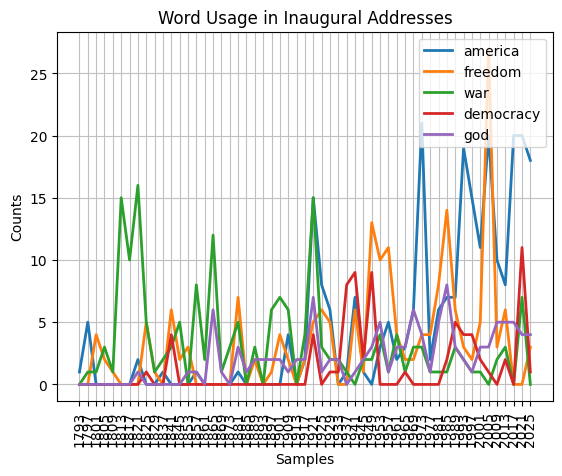

In [68]:
# Inaugural Address Corpus: presidential speeches 1789-2009
print('Inaugural files:', inaugural.fileids()[:5], '...')
print()
# Track word usage over time
import matplotlib.pyplot as plt
from nltk import ConditionalFreqDist

cfd_inaugural = ConditionalFreqDist(
    (word.lower(), fileid[:4])   # word, year
    for fileid in inaugural.fileids()
    for word in inaugural.words(fileid)
)
keywords = ['america', 'freedom', 'war', 'democracy', 'god']
cfd_inaugural.plot(conditions=keywords,
                   title='Word Usage in Inaugural Addresses')
plt.show()

## 2. Frequency Analysis

Frequency distributions reveal the statistical structure of language.
Zipf's Law: word frequency is inversely proportional to its rank.

In [69]:
from nltk import FreqDist
from nltk.corpus import gutenberg
import string

# Full frequency analysis of Emma
emma_words = [w.lower() for w in gutenberg.words('austen-emma.txt')]
fdist = FreqDist(emma_words)

print(f'Total tokens: {len(emma_words):,}')
print(f'Vocabulary size: {len(fdist):,}')
print(f'Most common 20: {fdist.most_common(20)}')
print(f'Hapaxes (first 15): {fdist.hapaxes()[:15]}')

Total tokens: 192,427
Vocabulary size: 7,344
Most common 20: [(',', 11454), ('.', 6928), ('to', 5239), ('the', 5201), ('and', 4896), ('of', 4291), ('i', 3178), ('a', 3129), ('it', 2528), ('her', 2469), ('was', 2398), ('she', 2340), (';', 2199), ('in', 2188), ('not', 2140), ('"', 2004), ('you', 1980), ('be', 1975), ('that', 1806), ('he', 1806)]
Hapaxes (first 15): ['austen', '1816', ']', 'vex', 'indistinct', 'caresses', 'nominal', 'mildness', 'impose', 'esteeming', 'disadvantages', 'misfortunes', 'mournful', 'debt', 'tenderer']


In [70]:
# Filtering for content words
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
content_words = [
    w for w in emma_words
    if w.isalpha() and w not in stop_words and len(w) > 2
]
fdist_content = FreqDist(content_words)
print('Content words (non-stopwords):')
print(fdist_content.most_common(20))

Content words (non-stopwords):
[('emma', 865), ('could', 837), ('would', 820), ('mrs', 699), ('miss', 599), ('must', 567), ('harriet', 506), ('much', 486), ('said', 484), ('one', 452), ('weston', 440), ('every', 435), ('well', 401), ('thing', 398), ('knightley', 389), ('elton', 385), ('think', 383), ('little', 359), ('never', 358), ('good', 358)]


In [71]:
# Concordance: word in context
from nltk.text import Text

emma_text = Text(gutenberg.words('austen-emma.txt'))
print('Concordance for "marriage":')
emma_text.concordance('marriage', width=60, lines=10)

Concordance for "marriage":
Displaying 10 of 35 matches:
equence of her sister ' s marriage , been mistress of his ho
oon followed Isabella ' s marriage , on their being left to 
ut she knows how much the marriage is to Miss Taylor ' s adv
years to bring about this marriage . A worthy employment for
 to be dissuaded from the marriage , and it took place , to 
d , after a three years ' marriage , he was rather a poorer 
 that , even in his first marriage ; but his second must she
Now , upon his father ' s marriage , it was very generally p
 congratulation which her marriage had already secured . She
nd since Mrs . Weston ' s marriage her exercise had been too


## 3. WordNet: A Lexical Database

**WordNet** is a large lexical database of English grouping words into synsets (synonym sets).

```
dog
├── synset: Canis_familiaris.n.01  (domestic dog)
│   ├── hypernym: canine (parent concept)
│   ├── hyponyms: poodle, terrier, beagle... (child concepts)
│   └── meronyms: tail, paw, fur... (parts of)
└── synset: frump.n.01  (informal, old-fashioned person)
```

**Key relations:**
- **Synonyms**: same synset
- **Hypernym**: more general (dog → canine → mammal → animal)
- **Hyponym**: more specific (dog → poodle, beagle)
- **Meronym**: part-of (dog → leg, tail)

In [72]:
from nltk.corpus import wordnet as wn
nltk.download('wordnet', quiet=True)

# Find synsets for 'car'
synsets = wn.synsets('car')
print('Synsets for "car":')
for s in synsets:
    print(f'  {s.name()}: {s.definition()}')
    print(f'    Examples: {s.examples()[:2]}')
    print()

Synsets for "car":
  car.n.01: a motor vehicle with four wheels; usually propelled by an internal combustion engine
    Examples: ['he needs a car to get to work']

  car.n.02: a wheeled vehicle adapted to the rails of railroad
    Examples: ['three cars had jumped the rails']

  car.n.03: the compartment that is suspended from an airship and that carries personnel and the cargo and the power plant
    Examples: []

  car.n.04: where passengers ride up and down
    Examples: ['the car was on the top floor']

  cable_car.n.01: a conveyance for passengers or freight on a cable railway
    Examples: ['they took a cable car to the top of the mountain']



In [73]:
# Exploring lexical relations
dog = wn.synset('dog.n.01')
print('Name:', dog.name())
print('Definition:', dog.definition())
print('Lemma names:', dog.lemma_names())
print()
print('Hypernyms (parents):',  [h.name() for h in dog.hypernyms()])
print('Hyponyms (children):',  [h.name() for h in dog.hyponyms()[:5]], '...')
print('Meronyms (parts):',     [m.name() for m in dog.part_meronyms()])
print('Holonyms (wholes):',    [h.name() for h in dog.member_holonyms()])

Name: dog.n.01
Definition: a member of the genus Canis (probably descended from the common wolf) that has been domesticated by man since prehistoric times; occurs in many breeds
Lemma names: ['dog', 'domestic_dog', 'Canis_familiaris']

Hypernyms (parents): ['canine.n.02', 'domestic_animal.n.01']
Hyponyms (children): ['dalmatian.n.02', 'corgi.n.01', 'pooch.n.01', 'lapdog.n.01', 'spitz.n.01'] ...
Meronyms (parts): ['flag.n.07']
Holonyms (wholes): ['pack.n.06', 'canis.n.01']


In [74]:
# Navigating the hypernym hierarchy (semantic tree)
motorcar = wn.synset('car.n.01')
print('Semantic hierarchy:')
for level, hypernym in enumerate(list(motorcar.closure(lambda s: s.hypernyms()))):
    print(f'  {"  "*level}{hypernym.name()}: {hypernym.definition()[:50]}')

Semantic hierarchy:
  motor_vehicle.n.01: a self-propelled wheeled vehicle that does not run
    self-propelled_vehicle.n.01: a wheeled vehicle that carries in itself a means o
      wheeled_vehicle.n.01: a vehicle that moves on wheels and usually has a c
        vehicle.n.01: a conveyance that transports people or objects
          container.n.01: any object that can be used to hold things (especi
            conveyance.n.03: something that serves as a means of transportation
              instrumentality.n.03: an artifact (or system of artifacts) that is instr
                artifact.n.01: a man-made object taken as a whole
                  whole.n.02: an assemblage of parts that is regarded as a singl
                    object.n.01: a tangible and visible entity; an entity that can 
                      physical_entity.n.01: an entity that has physical existence
                        entity.n.01: that which is perceived or known or inferred to ha


In [75]:
# Word Similarity with WordNet
dog = wn.synset('dog.n.01')
cat = wn.synset('cat.n.01')
hit = wn.synset('hit.v.01')
slug = wn.synset('slug.v.01')

pairs = [
    (wn.synset('dog.n.01'), wn.synset('cat.n.01'), 'dog / cat'),
    (wn.synset('dog.n.01'), wn.synset('wolf.n.01'), 'dog / wolf'),
    (wn.synset('dog.n.01'), wn.synset('table.n.01'), 'dog / table'),
    (wn.synset('car.n.01'), wn.synset('motorcycle.n.01'), 'car / motorcycle'),
]

print(f'{"Pair":<25} {"path_sim":<12} {"wup_sim"}')
print('-' * 50)
for s1, s2, label in pairs:
    path = s1.path_similarity(s2)
    wup = s1.wup_similarity(s2)
    print(f'{label:<25} {path:<12.4f} {wup:.4f}')

Pair                      path_sim     wup_sim
--------------------------------------------------
dog / cat                 0.2000       0.8571
dog / wolf                0.3333       0.9286
dog / table               0.0714       0.1333
car / motorcycle          0.3333       0.9167


## Practice Exercises

See **`Lecture-03-Homework.ipynb`** for the practice exercises accompanying this lecture.

## Summary

| Resource | Content | Access |
|----------|---------|--------|
| Gutenberg | Classic literature | `nltk.corpus.gutenberg` |
| Brown | Balanced genre corpus | `nltk.corpus.brown` |
| Reuters | Financial news | `nltk.corpus.reuters` |
| Inaugural | Presidential speeches | `nltk.corpus.inaugural` |
| WordNet | Lexical database | `nltk.corpus.wordnet` |

**Next Lecture**: Regular Expressions & Structured Text.

---
*Book references: NLP with Python Ch.2 | Practical NLP Ch.2*

---
**Author: Lei Wu | © 2026 Lei Wu. All rights reserved. Unauthorized use is prohibited.**